# Titanic???? / Titanic Survival Prediction

??Notebook???`train_local.csv`?`valid.csv`?`eval.csv`?????Titanic??????????????????

?????Accuracy???????EDA?????????????????????????`valid.csv`??????????????

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_DIR = Path(r"C:\Users\trana\Downloads")
OUTPUT_DIR = Path(r"C:\Users\trana\Documents\Codex\2026-05-08\files-mentioned-by-the-user-copy")

train = pd.read_csv(DATA_DIR / "train_local (1).csv")
valid = pd.read_csv(DATA_DIR / "valid (1).csv")
eval_df = pd.read_csv(DATA_DIR / "eval (1).csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

## Step1: ?????????

???????????????????????

In [2]:
for name, df in [("train", train), ("valid", valid), ("eval", eval_df), ("sample_submission", sample_submission)]:
    print(f"## {name}")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("missing values:")
    print(df.isna().sum())
    print()

## train
shape: (623, 12)
columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            119
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          487
Embarked         2
dtype: int64

## valid
shape: (134, 12)
columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             29
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          103
Embarked         0
dtype: int64

## eval
shape: (134, 11)
columns: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
missing values:
PassengerId     0
Pclass 

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
2,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
3,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
4,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


### Q1: ??????????

`Sex`????????????????????????????`Pclass`??????????????????????????????`Age`?????????????????`Fare`?????????????????????????`SibSp`?`Parch`????????????????????????????????????`Name`??`Mr`?`Mrs`?`Miss`?`Master`???????????????????????????????`Cabin`??????????????????????????????

## Step2: `Survived`??????????

In [4]:
print(train["Survived"].value_counts())
print(train["Survived"].value_counts(normalize=True).round(3))

Survived
0    384
1    239
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


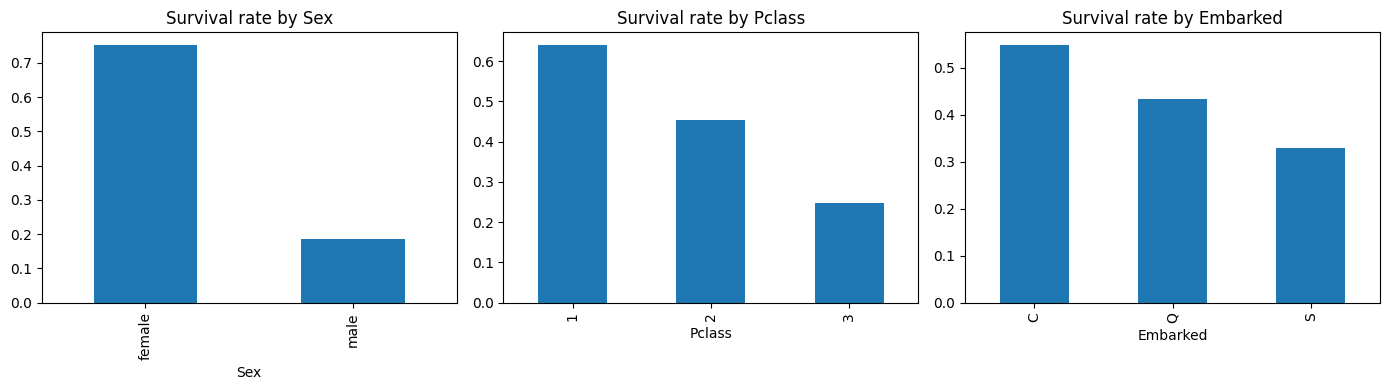

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
train.groupby("Sex")["Survived"].mean().plot(kind="bar", ax=axes[0], title="Survival rate by Sex")
train.groupby("Pclass")["Survived"].mean().plot(kind="bar", ax=axes[1], title="Survival rate by Pclass")
train.groupby("Embarked")["Survived"].mean().plot(kind="bar", ax=axes[2], title="Survival rate by Embarked")
plt.tight_layout()
plt.show()

In [6]:
print("Survival by Sex")
print(train.groupby("Sex")["Survived"].agg(["count", "mean"]).round(3))
print("\nSurvival by Pclass")
print(train.groupby("Pclass")["Survived"].agg(["count", "mean"]).round(3))
print("\nSurvival by Embarked")
print(train.groupby("Embarked")["Survived"].agg(["count", "mean"]).round(3))

Survival by Sex
        count   mean
Sex                 
female    217  0.751
male      406  0.187

Survival by Pclass
        count   mean
Pclass              
1         147  0.639
2         130  0.454
3         346  0.249

Survival by Embarked
          count   mean
Embarked              
C           124  0.548
Q            53  0.434
S           444  0.329


## Step3-Step4: ??????????????

??Notebook??`Pipeline`?`ColumnTransformer`????????????????????????????????One-Hot Encoding???

### Q3: ?????

`Age`????????????????????????????????????????`Embarked`??????????????????`Cabin`????????????????????????????`HasCabin`?`Deck`?????????????

### Q4: ?????????

`Sex`?`Embarked`???????`Title`?`Deck`?One-Hot Encoding??????????????`valid`?`eval`???????????`handle_unknown="ignore"`??????

In [7]:
def make_model(numeric_features, categorical_features, estimator):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])
    return Pipeline(steps=[("preprocess", preprocessor), ("model", estimator)])

## Step5: ?????????

EDA?????????????????????

- `FamilySize`: ??????????????????????????????????
- `IsAlone`: ???????????????????????????
- `Title`: ?????????????????????????????????
- `HasCabin`: ????????????????????????????????
- `Deck`: ?????????????????????????

In [8]:
def extract_title(name):
    title = name.split(",")[1].split(".")[0].strip()
    rare_titles = {"Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"}
    if title in rare_titles:
        return "Rare"
    if title in {"Mlle", "Ms"}:
        return "Miss"
    if title == "Mme":
        return "Mrs"
    return title


def add_features(df):
    df = df.copy()
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    df["Title"] = df["Name"].apply(extract_title)
    df["HasCabin"] = df["Cabin"].notna().astype(int)
    df["Deck"] = df["Cabin"].fillna("Unknown").astype(str).str[0]
    df.loc[df["Deck"] == "U", "Deck"] = "Unknown"
    return df

train_fe = add_features(train)
valid_fe = add_features(valid)
eval_fe = add_features(eval_df)
train_fe[["FamilySize", "IsAlone", "Title", "HasCabin", "Deck"]].head()

,FamilySize,IsAlone,Title,HasCabin,Deck
0,2,0,Mr,0,Unknown
1,1,1,Miss,0,Unknown
2,2,0,Mrs,1,C
3,1,1,Mr,0,Unknown
4,1,1,Mr,1,E


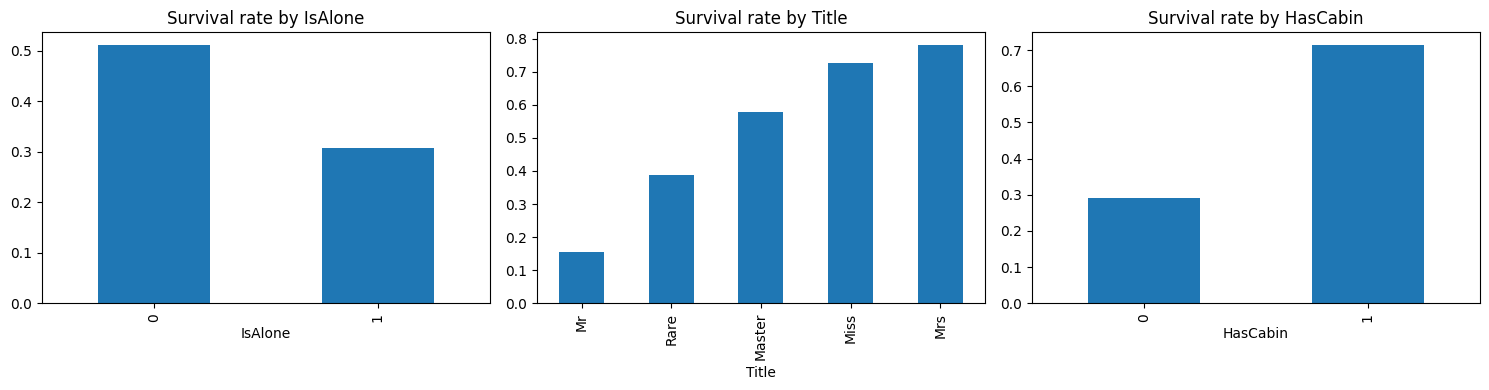

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train_fe.groupby("IsAlone")["Survived"].mean().plot(kind="bar", ax=axes[0], title="Survival rate by IsAlone")
train_fe.groupby("Title")["Survived"].mean().sort_values().plot(kind="bar", ax=axes[1], title="Survival rate by Title")
train_fe.groupby("HasCabin")["Survived"].mean().plot(kind="bar", ax=axes[2], title="Survival rate by HasCabin")
plt.tight_layout()
plt.show()

## Step6-Step7: ??????`valid.csv`????

????????????`Pclass`?`Sex`?`Age`?`Fare`?`Embarked`?????????????????????????

In [10]:
y_train = train["Survived"]
y_valid = valid["Survived"]

experiments = [
    ("baseline_logreg", train, valid, ["Pclass", "Age", "Fare"], ["Sex", "Embarked"], LogisticRegression(max_iter=1000, random_state=42)),
    ("baseline_rf", train, valid, ["Pclass", "Age", "Fare"], ["Sex", "Embarked"], RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=4, random_state=42)),
    ("feature_logreg", train_fe, valid_fe, ["Pclass", "Age", "Fare", "SibSp", "Parch", "FamilySize", "IsAlone", "HasCabin"], ["Sex", "Embarked", "Title", "Deck"], LogisticRegression(max_iter=1000, random_state=42)),
    ("feature_rf", train_fe, valid_fe, ["Pclass", "Age", "Fare", "SibSp", "Parch", "FamilySize", "IsAlone", "HasCabin"], ["Sex", "Embarked", "Title", "Deck"], RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=3, random_state=42)),
    ("feature_gb", train_fe, valid_fe, ["Pclass", "Age", "Fare", "SibSp", "Parch", "FamilySize", "IsAlone", "HasCabin"], ["Sex", "Embarked", "Title", "Deck"], GradientBoostingClassifier(n_estimators=120, learning_rate=0.04, max_depth=3, random_state=42)),
]

rows = []
fitted_models = {}
for name, tr, va, nums, cats, estimator in experiments:
    model = make_model(nums, cats, estimator)
    model.fit(tr, y_train)
    pred = model.predict(va)
    acc = accuracy_score(y_valid, pred)
    rows.append({"experiment": name, "accuracy": acc, "numeric_features": ", ".join(nums), "categorical_features": ", ".join(cats)})
    fitted_models[name] = (model, tr, va, nums, cats)

results = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
results

,experiment,accuracy,numeric_features,categorical_features
2,feature_logreg,0.873134,"Pclass, Age, Fare, SibSp, Parch, FamilySize, I...","Sex, Embarked, Title, Deck"
3,feature_rf,0.873134,"Pclass, Age, Fare, SibSp, Parch, FamilySize, I...","Sex, Embarked, Title, Deck"
4,feature_gb,0.850746,"Pclass, Age, Fare, SibSp, Parch, FamilySize, I...","Sex, Embarked, Title, Deck"
1,baseline_rf,0.820896,"Pclass, Age, Fare","Sex, Embarked"
0,baseline_logreg,0.805970,"Pclass, Age, Fare","Sex, Embarked"


### Q2: ?????????

????????????`Pclass`?`Sex`?`Age`?`Fare`?`Embarked`?????`baseline_logreg`?Accuracy??`0.806`?`baseline_rf`?Accuracy??`0.821`?????

### Q5: ??????????

`FamilySize`?`IsAlone`?`Title`?`HasCabin`?`Deck`?????????????????????????????????????????????????????????????`feature_logreg`?`feature_rf`?Accuracy?`0.873`?????????????????

In [11]:
best_name = results.iloc[0]["experiment"]
best_model = fitted_models[best_name][0]
best_valid_df = fitted_models[best_name][2]
valid_pred = best_model.predict(best_valid_df)

print("Best model:", best_name)
print("Valid accuracy:", accuracy_score(y_valid, valid_pred))
print("Confusion matrix:")
print(confusion_matrix(y_valid, valid_pred))
print("\nClassification report:")
print(classification_report(y_valid, valid_pred))

Best model: feature_logreg
Valid accuracy: 0.8731343283582089
Confusion matrix:
[[73  9]
 [ 8 44]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90        82
           1       0.83      0.85      0.84        52

    accuracy                           0.87       134
   macro avg       0.87      0.87      0.87       134
weighted avg       0.87      0.87      0.87       134



## Step8: `eval.csv`??????CSV?????

???CSV?`PassengerId,Survived`?2???????

In [12]:
best_eval_df = eval_fe if str(best_name).startswith("feature") else eval_df
eval_pred = best_model.predict(best_eval_df)
submission = pd.DataFrame({
    "PassengerId": eval_df["PassengerId"],
    "Survived": eval_pred.astype(int),
})

submission_path = OUTPUT_DIR / "submission_eval.csv"
results_path = OUTPUT_DIR / "titanic_experiment_results.csv"
submission.to_csv(submission_path, index=False)
results.to_csv(results_path, index=False)

print("saved:", submission_path)
print("saved:", results_path)
print("shape:", submission.shape)
print("Survived values:", submission["Survived"].value_counts().to_dict())
submission.head()

saved: C:\Users\trana\Documents\Codex\2026-05-08\files-mentioned-by-the-user-copy\submission_eval.csv
saved: C:\Users\trana\Documents\Codex\2026-05-08\files-mentioned-by-the-user-copy\titanic_experiment_results.csv
shape: (134, 2)
Survived values: {0: 86, 1: 48}


,PassengerId,Survived
0,2,1
1,5,0
2,8,0
3,10,1
4,39,0


## ???

EDA???`Sex`?`Pclass`?`Title`?`HasCabin`?????????????????????????Pipeline?????????????One-Hot Encoding??????????????????????????????`valid.csv`?Accuracy??????